In [1]:
################################################################################
###                                                                          ###
### Created by Haotian XIAO, 2024-2027                                       ###
###                                                                          ###
### École Polytechnique, Palaiseau, France                                   ###
###                                                                          ###
###                                                                          ###
### And Martin Genet, 2018-2025                                              ###
###                                                                          ###
### École Polytechnique, Palaiseau, France                                   ###
###                                                                          ###
################################################################################

#################################################################### imports ###




In [2]:
import os
import math
import dolfin
import myPythonLibrary as mypy
import dolfin_mech as dmech


mat_params = {
    "alpha": 0.16,
    "gamma": 0.5,
    "c1": 0.2,
    "c2": 0.4,
    "kappa": 1,
    "eta": 1e-5,
}

dim = 2
bcs = "pbc"


def make_solid_loading(
    mode,
    n_steps,
    Umax=0.3,
    beta=0.3,
):
    solid_loading = {}

    if mode == "stretch_x":
        solid_loading["U_bar_00_lst"] = [0.0, Umax]

    elif mode == "volumic":
        solid_loading["U_bar_00_lst"] = [0.0, Umax]
        solid_loading["U_bar_11_lst"] = [0.0, Umax]

    elif mode == "simple_shear":
        solid_loading["U_bar_00_lst"] = [0.0, 0.0]
        solid_loading["U_bar_01_lst"] = [0.0, beta]
        solid_loading["U_bar_10_lst"] = [0.0, 0.0]
        solid_loading["U_bar_11_lst"] = [0.0, 0.0]

    elif mode == "gas_pressure":
        solid_loading["U_bar_00_lst"] = [0.0, 0.0]
        solid_loading["U_bar_01_lst"] = [0.0, 0.0]
        solid_loading["U_bar_10_lst"] = [0.0, 0.0]
        solid_loading["U_bar_11_lst"] = [0.0, 0.0]

    else:
        raise ValueError(
            "mode must be 'stretch_x', 'volumic', 'simple_shear', or 'gas_pressure'"
        )

    return solid_loading


def run_one_probe(
    r0,
    probe,
    mode,
    res_folder,
    prefix,
    pg=0.2,
    Umax=0.3,
    beta=0.3,
):
    if mode not in ["stretch_x", "volumic", "simple_shear", "gas_pressure"]:
        raise ValueError(
            "mode must be 'stretch_x', 'volumic', 'simple_shear', or 'gas_pressure'"
        )

    if probe == "gx":
        gx_fin_lst = [0.01, 0.01]
        gy_fin_lst = [0.0, 0.0]
    elif probe == "gy":
        gx_fin_lst = [0.0, 0.0]
        gy_fin_lst = [0.01, 0.01]
    else:
        raise ValueError("probe must be 'gx' or 'gy'")

    n_steps = 2

    if mode == "gas_pressure":
        pf_lst = [0.0, pg]
        pf_tag = pg
    else:
        pf_lst = [0.0, 0.0]
        pf_tag = 0.0

    res_basename = f"{prefix}-{mode}-r0={r0}-pf={pf_tag}-{probe}"

    load_params = {
        "solid": {},
        "liquid": {},
        "air": {},
    }

    for i in range(dim):
        for j in range(dim):
            load_params["solid"]["sigma_bar_" + str(i) + str(j)] = 0.0

    load_params["liquid"]["pl_bar_ini_lst"] = [0.0] * n_steps
    load_params["liquid"]["pl_bar_fin_lst"] = [0.0] * n_steps

    load_params["liquid"]["grad_p_bar_x_ini_lst"] = [0.0] * n_steps
    load_params["liquid"]["grad_p_bar_x_fin_lst"] = gx_fin_lst

    load_params["liquid"]["grad_p_bar_y_ini_lst"] = [0.0] * n_steps
    load_params["liquid"]["grad_p_bar_y_fin_lst"] = gy_fin_lst

    load_params["liquid"]["Theta_in_ini_lst"] = [0.0] * n_steps
    load_params["liquid"]["Theta_in_fin_lst"] = [0.0] * n_steps
    load_params["liquid"]["Theta_out_ini_lst"] = [0.0] * n_steps
    load_params["liquid"]["Theta_out_fin_lst"] = [0.0] * n_steps

    solid_loading = make_solid_loading(
        mode=mode,
        n_steps=n_steps,
        Umax=Umax,
        beta=beta,
    )

    for key, val in solid_loading.items():
        load_params["solid"][key] = val

    load_params["air"]["pf_lst"] = pf_lst

    dmech.run_HollowBox_MicroPoroflow(
        dim=dim,
        mesh_params={
            "dim": dim,
            "xmin": 0.0,
            "ymin": -math.sqrt(3) / 2,
            "xmax": 1.0,
            "ymax": math.sqrt(3) / 2,
            "r0": r0,
            "l": 0.03,
            "hole_shape": "hex",
            "add_center_hole": True,
            "mesh_filebasename": res_folder + f"/mesh-{mode}-r0={r0}-{probe}",
        },
        mat_params={
            "skel": {"parameters": mat_params, "scaling": "no"},
            "bulk": {"parameters": mat_params, "scaling": "no"},
            "pore": {"parameters": mat_params, "scaling": "no"},
        },
        flow_params={
            "k_l": dolfin.Constant(
                (
                    (1e-6, 0.0),
                    (0.0, 1e-6),
                )
            ),
            "use_kozeny_carman": False,
        },
        porosity_params={
            "type": "constant",
            "val": 0.3,
        },
        bcs=bcs,
        step_params={
            "n_steps": n_steps,
            "Deltat_lst": [1e-2, 1e-1],
            "dt_ini_lst": [1e-3, 1e-3],
            "dt_min_lst": [1e-4, 1e-4],
            "dt_max_lst": [5e-3, 5e-3],
        },
        load_params=load_params,
        res_basename=res_folder + "/" + res_basename,
        verbose=0,
    )


def run_four_loading_cases(
    r0_list=(0.072, 0.41, 0.5),
    mode_list=("stretch_x", "volumic", "simple_shear", "gas_pressure"),
    probe_list=("gx", "gy"),
    pg=0.5,
    Umax=0.3,
    beta=0.3,
    res_folder="results_four_loading_cases",
    prefix="Fig_loading",
    perform_tests=0,
):
    os.makedirs(res_folder, exist_ok=True)

    test = mypy.Test(
        res_folder=res_folder,
        perform_tests=perform_tests,
        stop_at_failure=1,
        clean_after_tests=0,
        tester_numpy_tolerance=1e-2,
    )

    for mode in mode_list:
        for r0 in r0_list:
            for probe in probe_list:
                print("")
                print("========================================")
                print(f"Running mode={mode}, r0={r0}, pg={pg}, probe={probe}")
                print("========================================")

                if mode == "gas_pressure":
                    pf_tag = pg
                else:
                    pf_tag = 0.0

                res_basename = f"{prefix}-{mode}-r0={r0}-pf={pf_tag}-{probe}"

                run_one_probe(
                    r0=r0,
                    probe=probe,
                    mode=mode,
                    res_folder=res_folder,
                    prefix=prefix,
                    pg=pg,
                    Umax=Umax,
                    beta=beta,
                )

                test.test(res_folder + "/" + res_basename)

    return res_folder

In [3]:
r0_list = [0.07, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.41, 0.45]
run_four_loading_cases(
    r0_list=r0_list,
    mode_list=("stretch_x", "volumic", "simple_shear", "gas_pressure"),
    probe_list=("gx", "gy"),
    pg=0.5,
    Umax=0.3,
    beta=0.3,
    res_folder="results_four_loading_cases",
    prefix="Fig_loading",
)


Running mode=stretch_x, r0=0.07, pg=0.5, probe=gx
Info    : Reconstructing periodicity for curve connection 6 - 12                                             
Info    : Reconstructing periodicity for curve connection 9 - 3
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 20%] Meshing curve 3 (Line)
Info    : [ 20%] Meshing curve 4 (Line)
Info    : [ 30%] Meshing curve 5 (Line)
Info    : [ 40%] Meshing curve 7 (Line)
Info    : [ 40%] Meshing curve 8 (Line)
Info    : [ 50%] Meshing curve 9 (Line) as a copy of curve 3
Info    : [ 60%] Meshing curve 10 (Line)
Info    : [ 60%] Meshing curve 11 (Line)
Info    : [ 70%] Meshing curve 12 (Line)
Info    : [ 70%] Meshing curve 13 (Line)
Info    : [ 80%] Meshing curve 14 (Line)
Info    : [ 80%] Meshing curve 15 (Line)
Info    : [ 90%] Meshing curve 16 (Line)
Info    : [ 90%] Meshing curve 17 (Line)
Info    : [100%] Meshing curve 18 (Line)
Info    : [100%] Meshing curve 6 (Line) a

/opt/anaconda3/envs/dolfin-clean/lib/python3.10/site-packages/ufl/exproperators.py:336: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if arg in ("+", "-"):


Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.


/opt/anaconda3/envs/dolfin-clean/lib/python3.10/site-packages/ufl/exproperators.py:336: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if arg in ("+", "-"):



Running mode=stretch_x, r0=0.07, pg=0.5, probe=gy
Info    : Reconstructing periodicity for curve connection 6 - 12                                             
Info    : Reconstructing periodicity for curve connection 9 - 3
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 20%] Meshing curve 3 (Line)
Info    : [ 20%] Meshing curve 4 (Line)
Info    : [ 30%] Meshing curve 5 (Line)
Info    : [ 40%] Meshing curve 7 (Line)
Info    : [ 40%] Meshing curve 8 (Line)
Info    : [ 50%] Meshing curve 9 (Line) as a copy of curve 3
Info    : [ 60%] Meshing curve 10 (Line)
Info    : [ 60%] Meshing curve 11 (Line)
Info    : [ 70%] Meshing curve 12 (Line)
Info    : [ 70%] Meshing curve 13 (Line)
Info    : [ 80%] Meshing curve 14 (Line)
Info    : [ 80%] Meshing curve 15 (Line)
Info    : [ 90%] Meshing curve 16 (Line)
Info    : [ 90%] Meshing curve 17 (Line)
Info    : [100%] Meshing curve 18 (Line)
Info    : [100%] Meshing curve 6 (Line) a

...

/opt/anaconda3/envs/dolfin-clean/lib/python3.10/site-packages/ufl/exproperators.py:336: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if arg in ("+", "-"):


Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.


/opt/anaconda3/envs/dolfin-clean/lib/python3.10/site-packages/ufl/exproperators.py:336: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if arg in ("+", "-"):



Running mode=gas_pressure, r0=0.45, pg=0.5, probe=gy
Info    : Reconstructing periodicity for curve connection 6 - 12                                             
Info    : Reconstructing periodicity for curve connection 9 - 3
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 20%] Meshing curve 3 (Line)
Info    : [ 20%] Meshing curve 4 (Line)
Info    : [ 30%] Meshing curve 5 (Line)
Info    : [ 40%] Meshing curve 7 (Line)
Info    : [ 40%] Meshing curve 8 (Line)
Info    : [ 50%] Meshing curve 9 (Line) as a copy of curve 3
Info    : [ 60%] Meshing curve 10 (Line)
Info    : [ 60%] Meshing curve 11 (Line)
Info    : [ 70%] Meshing curve 12 (Line)
Info    : [ 70%] Meshing curve 13 (Line)
Info    : [ 80%] Meshing curve 14 (Line)
Info    : [ 80%] Meshing curve 15 (Line)
Info    : [ 90%] Meshing curve 16 (Line)
Info    : [ 90%] Meshing curve 17 (Line)
Info    : [100%] Meshing curve 18 (Line)
Info    : [100%] Meshing curve 6 (Line

'results_four_loading_cases'

PROJECT_DIR = /Users/xiao/PhD/Project_MicroPoroFlow
SRC_DIR = /Users/xiao/PhD/Project_MicroPoroFlow/src


2026-06-23 21:41:59.618 (   0.021s) [          6F92D3]     vtkGenericCell.cxx:439    ERR| vtkGenericCell (0x117fc9e90): Unsupported cell type: 51 Setting to vtkEmptyCell
2026-06-23 21:41:59.618 (   0.021s) [          6F92D3]     vtkGenericCell.cxx:439    ERR| vtkGenericCell (0x117fc9e90): Unsupported cell type: 52 Setting to vtkEmptyCell
2026-06-23 21:41:59.618 (   0.021s) [          6F92D3]     vtkGenericCell.cxx:439    ERR| vtkGenericCell (0x117fc9e90): Unsupported cell type: 53 Setting to vtkEmptyCell
2026-06-23 21:41:59.618 (   0.021s) [          6F92D3]     vtkGenericCell.cxx:439    ERR| vtkGenericCell (0x117fc9e90): Unsupported cell type: 54 Setting to vtkEmptyCell
2026-06-23 21:41:59.618 (   0.021s) [          6F92D3]     vtkGenericCell.cxx:439    ERR| vtkGenericCell (0x117fc9e90): Unsupported cell type: 55 Setting to vtkEmptyCell
2026-06-23 21:41:59.618 (   0.021s) [          6F92D3]     vtkGenericCell.cxx:439    ERR| vtkGenericCell (0x117fc9e90): Unsupported cell type: 56 Sett

uniaxial loading, r0=0.07, phi=0.014700, C_K=1.056145, A_K=2.128078, E_K=0.032688
uniaxial loading, r0=0.1, phi=0.030000, C_K=1.034165, A_K=2.051511, E_K=0.061227
uniaxial loading, r0=0.15, phi=0.067500, C_K=0.990763, A_K=1.895014, E_K=0.123299
uniaxial loading, r0=0.2, phi=0.120000, C_K=0.948060, A_K=1.732503, E_K=0.193264
[WARNING] Uyy differs between gx and gy for mode=stretch_x, r0=0.25
uniaxial loading, r0=0.25, phi=0.187500, C_K=0.913262, A_K=1.587666, E_K=0.259743
[WARNING] Uyy differs between gx and gy for mode=stretch_x, r0=0.3
uniaxial loading, r0=0.3, phi=0.270000, C_K=0.888271, A_K=1.468880, E_K=0.317307
[WARNING] Uyy differs between gx and gy for mode=stretch_x, r0=0.35
uniaxial loading, r0=0.35, phi=0.367500, C_K=0.872119, A_K=1.374559, E_K=0.368135
[WARNING] Uyy differs between gx and gy for mode=stretch_x, r0=0.41
uniaxial loading, r0=0.41, phi=0.504300, C_K=0.863812, A_K=1.285575, E_K=0.431506
[WARNING] Uyy differs between gx and gy for mode=stretch_x, r0=0.45
uniaxial

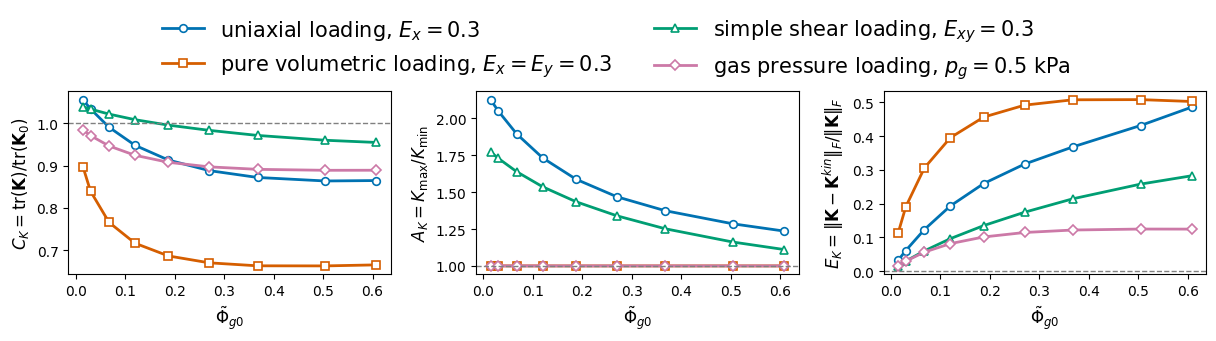

Saved: plots/Figure9_summary.png


In [1]:
from pathlib import Path
import sys
r0_list = [0.07, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.41, 0.45]
PROJECT_DIR = Path.cwd().parents[0]
SRC_DIR = PROJECT_DIR / "src"

sys.path.insert(0, str(SRC_DIR))
print("PROJECT_DIR =", PROJECT_DIR)
print("SRC_DIR =", SRC_DIR)

from Plot_Microporoflow import plot_figure9_summary

rows = plot_figure9_summary(
    r0_list=r0_list,
    res_folder="results_four_loading_cases",
    prefix="Fig_loading",
    pg=0.5,
    save_name="plots/Figure9_summary.png",
    show_plot=True,
)